<a href="https://colab.research.google.com/github/micplachta/um2026/blob/main/lab03_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework Assignment: Optimizing the Classification Threshold in Logistic Regression**

-------------------------------

In this assignment, you will explore the concept of **classification thresholds** in **Logistic Regression** and investigate whether the commonly used threshold of **0.5** is always the optimal choice. To complete this assignment, you will need to conduct **additional reading** on **ROC curves** and the **AUC metric**, beyond the materials covered in class.

This exercise focuses on the **importance of threshold selection** and how it impacts model performance based on different evaluation criteria.



## **The Objective**

**Is a 0.5 threshold always the best choice in Logistic Regression?**

- Analyze if the standard threshold of **0.5** always yields the most desirable results in various scenarios.
- Investigate alternative thresholds and how they can improve model performance depending on the problem context.



## **Helper Questions**

1. **Would a different threshold yield better results?**  
   - How does shifting the threshold affect the **trade-off between sensitivity and specificity**?

2. **How do you define "better" results?**  
   - Is **higher specificity** more valuable than **higher sensitivity** in certain contexts? Or maybe the other way around?
   - Does the **best threshold** depend on the task? (discuss cases like *disease detection* vs. *spam filtering*)

3. **How does a ROC curve help in this process?**  
   - Learn how to use a **ROC curve** to visualize the trade-off between **True Positive Rate (Sensitivity)** and **False Positive Rate (1 - Specificity)**.

4. **How do you select the optimal threshold using the ROC curve?**  
   - Discuss strategies to select a threshold depending on the specific task at hand and the acceptable **trade-off between sensitivity and specificity**.

5. **What is the AUC metric and how is it useful?**  
   - Define **AUC (Area Under the Curve)** and discuss its role in evaluating the overall performance of a classifier.



## **Tasks & Deliverables**

1. **Colab Notebook**
   - Select a suitable classification 2-class dataset.
   - Divide the dataset into three parts: **train**, **validation**, and **test**.
   - Train the **Logistic Regression** model on the **training** set.
   - Use the **validation** set to:
     - Plot the **ROC curve**.
     - Calculate the **AUC**.
     - Determine the **optimal threshold** using the ROC curve for your dataset.
   - Apply the selected threshold to the **test** set to evaluate final model performance using metrics like:
     - **Accuracy**
     - **Precision & Recall**
     - **F1-Score**
     - **Specificity & Sensitivity**

2. **Answer the Questions:**
   - Use markdown cells to provide explanations.
   - Answer all helper questions with supporting evidence from your plots and results.

3. **Visualizations:**
   - **ROC curve** based on the **validation** set with threshold points marked.
   - Highlight the **optimal threshold** on the ROC curve.

4. **Publish on GitHub**  
   - Place the Colab notebook in your **GitHub repository** for this course.
   - In your repository’s **README**, add a **link** to the notebook and also include an **“Open in Colab”** badge at the top of the notebook so it can be launched directly from GitHub.




In [23]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [24]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

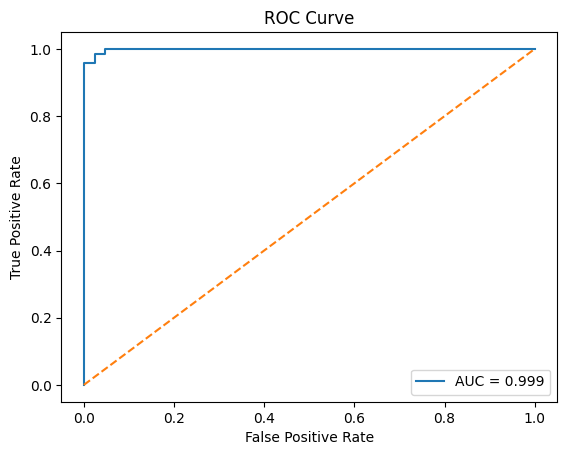

In [25]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

y_val_probs = model.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_val_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [26]:
J = tpr - fpr
best_idx = np.argmax(J)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

Best threshold: 0.6884661625269793


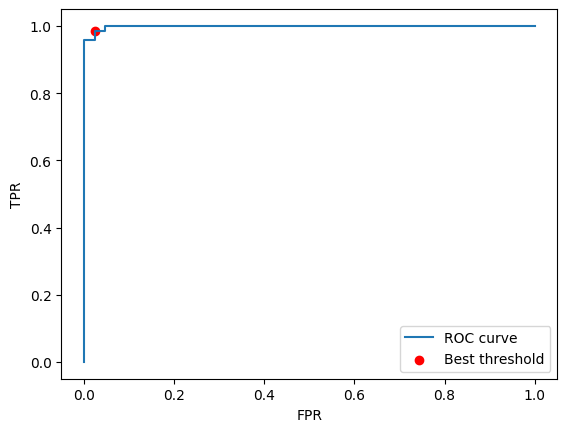

In [27]:
plt.figure()
plt.plot(fpr, tpr, label="ROC curve")
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label="Best threshold")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

In [35]:
def show_metrics(threshold):
    y_test_probs = model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_probs >= threshold).astype(int)

    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))
    print("F1:", f1_score(y_test, y_test_pred))

    cm = confusion_matrix(y_test, y_test_pred)
    print("Confusion matrix:\n", cm)

    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)

    print("Sensitivity:", sensitivity)
    print("Specificity:", specificity)

print(f"Metrics for {best_threshold:.3f}")
show_metrics(best_threshold)

print("\nMetrics for 0.5")
show_metrics(0.5)

Metrics for 0.688
Accuracy: 0.9473684210526315
Precision: 0.9861111111111112
Recall: 0.9342105263157895
F1: 0.9594594594594594
Confusion matrix:
 [[37  1]
 [ 5 71]]
Sensitivity: 0.9342105263157895
Specificity: 0.9736842105263158

Metrics for 0.5
Accuracy: 0.9649122807017544
Precision: 0.9864864864864865
Recall: 0.9605263157894737
F1: 0.9733333333333334
Confusion matrix:
 [[37  1]
 [ 3 73]]
Sensitivity: 0.9605263157894737
Specificity: 0.9736842105263158


I've chosen to use the breast cancer Wisconsin dataset which has entries consisting of 30 features and 1 categorical variable which indicates whether the corresponding patient indeed had breast cancer.

The logistic regression outputs the probability that an observation belongs to a particular class, while the classification threshold determines how these probabilities are converted into final decisions. Due to noise in the data and the fact that real-world relationships are often not perfectly linear, logistic regression makes both kinds of mistakes - false positives and false negatives, regardless of the chosen threshold. That threshold however conrols the balance between these errors and defines whether the test prioritizes sensitivity or specificity.

The threshold of 0.5 is commonly used as that means simply choosing the class that has a higher predicted probabilty. That is however often not the most appropriate policy. A perfect example of that is the dataset used above. Failing to detect breast cancer is MUCH WORSE than a false positive result so the test needs to be sensitive. An opposite example could be detection of spam in emails. We don't want important mail to be accidentally flagged as spam and hidden from us, thus in that case the test needs to be specific.

The ROC curve shows the relation between sensitivity and specificity for different values of threshold. It can be used to compare the performance of different models and also for choosing the most satisfying threshold. In general the closer the curve is to the top left corner (a perfect classifier) the better the model is.

Given the ROC curve there are several methods that can be used to choose the best threshold:
- maximize the Youden's J-statistic $J = Tpr - Fpr$ which is the difference between true positive rate and false positive rate
- minimize the distance from $(0, 1)$ ie. minimize $\sqrt{Fpr^2 + (1-Tpr)^2}$
- or do something more advanced taking into account domain requirements
Above I use the J-statistic to choose the best threshold.

Another metric that can be used is the AUC - Area Under Curve. It is used to evaluate the model across all thresholds and is defined as
$$
AUC = \int_0^1 Tpr(t) d(Fpr(t))
$$
with the values ranging from 0 to 1. The value of 0.5 corresponds to random guessing and the value of 1 to perfect classification. In general the higher the value the better. Values below 0.5 indicate programmer error ;)


In my experiment with the breast cancer dataset the best threshold turned out to be 0.688 giving a solid 0.947 accuracy. The logistic classifier got an impressive AUC of 0.999! This indicates that the model has an excellent ability to distinguish between the two classes.

Surprisingly even though the ROC based optimization suggested the best threshold of 0.688 it turned out to perform worse that 0.5 which achieved better accuracy and sensitivity on the test set. This may be caused by being unlucky with the data distribution in validation/test sets. What is also important is that the J-statistic doesn't give us the best threshold for the breast cancer test which should maximize sensitivity (although the lower accuracy is probably just unfortunate data).